# Momentum Regime Analysis
## 01 - Data Collection
This notebook pulls historical price data for S&P 500 sector ETFs from Yahoo Finance and prepares it for analysis.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# S&P 500 Sector ETFs
# These 11 ETFs together make up the entire S&P 500, broken into sectors
tickers = [
    "XLB",  # Materials
    "XLC",  # Communication Services
    "XLE",  # Energy
    "XLF",  # Financials
    "XLI",  # Industrials
    "XLK",  # Technology
    "XLP",  # Consumer Staples
    "XLRE", # Real Estate
    "XLU",  # Utilities
    "XLV",  # Health Care
    "XLY",  # Consumer Discretionary
]

# Pull adjusted closing prices from 2010 to present
raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]

print(raw.shape)
print(raw.head())

[*********************100%***********************]  11 of 11 completed

(4116, 11)
Ticker            XLB  XLC        XLE       XLF        XLI       XLK  \
Date                                                                   
2010-01-04  12.016512  NaN  17.268267  8.942387  20.922789  9.378781   
2010-01-05  12.055367  NaN  17.409203  9.106747  20.996674  9.366688   
2010-01-06  12.260235  NaN  17.617682  9.125010  21.040998  9.261899   
2010-01-07  12.164862  NaN  17.591253  9.319808  21.270025  9.225627   
2010-01-08  12.334412  NaN  17.705769  9.265020  21.609869  9.286087   

Ticker            XLP  XLRE       XLU        XLV        XLY  
Date                                                         
2010-01-04  17.250774   NaN  8.886091  23.984844  12.308617  
2010-01-05  17.257244   NaN  8.780309  23.749630  12.353746  
2010-01-06  17.244303   NaN  8.831770  23.992434  12.370158  
2010-01-07  17.244303   NaN  8.791741  24.075899  12.472734  
2010-01-08  17.186096   NaN  8.783169  24.113838  12.468628  


In [3]:
# Drop any columns that are entirely NaN 
prices = raw.dropna(axis=1, how="all")

# Calculate daily log returns
log_returns = np.log(prices / prices.shift(1))

# Drop the first row (NaN from the shift)
log_returns = log_returns.dropna(how="all")

print(f"Price data: {prices.shape[0]} days, {prices.shape[1]} tickers")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nSample log returns:")
print(log_returns.head())

Price data: 4116 days, 11 tickers
Date range: 2010-01-04 to 2026-05-14

Sample log returns:
Ticker           XLB  XLC       XLE       XLF       XLI       XLK       XLP  \
Date                                                                          
2010-01-05  0.003228  NaN  0.008128  0.018213  0.003525 -0.001290  0.000375   
2010-01-06  0.016851  NaN  0.011904  0.002003  0.002109 -0.011250 -0.000750   
2010-01-07 -0.007809  NaN -0.001501  0.021123  0.010826 -0.003924  0.000000   
2010-01-08  0.013841  NaN  0.006489 -0.005896  0.015851  0.006532 -0.003381   
2010-01-11 -0.005456  NaN -0.001327  0.000657  0.010881 -0.003914  0.002630   

Ticker      XLRE       XLU       XLV       XLY  
Date                                            
2010-01-05   NaN -0.011976 -0.009855  0.003660  
2010-01-06   NaN  0.005844  0.010172  0.001328  
2010-01-07   NaN -0.004543  0.003473  0.008258  
2010-01-08   NaN -0.000976  0.001575 -0.000329  
2010-01-11   NaN  0.010363  0.005648 -0.001976  


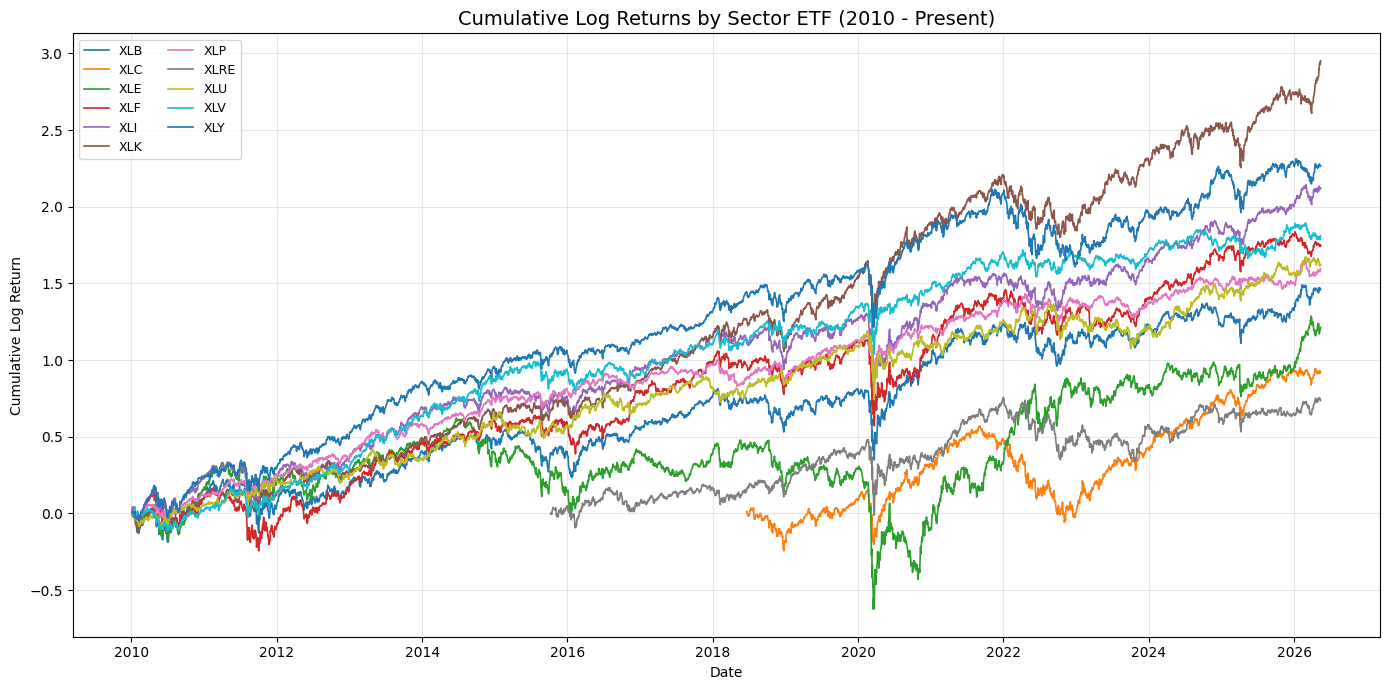

In [4]:
# Plot cumulative returns for each sector ETF
# Cumulative log returns = sum of daily log returns over time
cumulative_returns = log_returns.cumsum()

fig, ax = plt.subplots(figsize=(14, 7))

for ticker in cumulative_returns.columns:
    ax.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker, linewidth=1.2)

ax.set_title("Cumulative Log Returns by Sector ETF (2010 - Present)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Log Return")
ax.legend(loc="upper left", ncol=2, fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/cumulative_returns.png", dpi=150)
plt.show()